# CS

Paper-style Collins-Soper figure built from the extracted inputs in `extracted CS/`, using the original `Collins Soper.ipynb` layout as the reference.


In [1]:
from pathlib import Path
from shutil import which

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
from scipy.interpolate import interp1d

if which('latex'):
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})
    plt.rc('text', usetex=True)
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'

BASE_CANDIDATES = [
    Path('extracted CS'),
    Path('Replica Analysis') / 'extracted CS',
    Path('TMD-Fits-Minimal') / 'Replica Analysis' / 'extracted CS',
]
for candidate in BASE_CANDIDATES:
    if candidate.exists():
        BASE = candidate.resolve()
        break
else:
    raise FileNotFoundError('Could not find extracted CS/')

GEV_PER_FM = 5.068
print(f'Using extracted CS directory: {BASE}')


Using extracted CS directory: C:\Users\congyue zhang\Desktop\OpenCL fitter\TMD-Fits-Minimal\Replica Analysis\extracted CS


In [2]:
def load_edge_band(lo_name, up_name, grid_size=500):
    lo = pd.read_csv(BASE / lo_name, header=None, names=['b', 'lower']).sort_values('b')
    up = pd.read_csv(BASE / up_name, header=None, names=['b', 'upper']).sort_values('b')

    b_min = max(float(lo['b'].min()), float(up['b'].min()))
    b_max = min(float(lo['b'].max()), float(up['b'].max()))
    b_grid = np.linspace(b_min, b_max, grid_size)

    lo_values = np.interp(b_grid, lo['b'], lo['lower'])
    up_values = np.interp(b_grid, up['b'], up['upper'])
    lower = np.minimum(lo_values, up_values)
    upper = np.maximum(lo_values, up_values)
    return pd.DataFrame({'b': b_grid, 'lower': lower, 'upper': upper})


def d_to_k_band(df):
    k1 = -2.0 * df['lower'].to_numpy(dtype=float)
    k2 = -2.0 * df['upper'].to_numpy(dtype=float)
    return pd.DataFrame(
        {
            'b': df['b'].to_numpy(dtype=float),
            'lower': np.minimum(k1, k2),
            'upper': np.maximum(k1, k2),
        }
    )


def load_bbstar():
    df = pd.read_csv(BASE / 'bbstar.csv')
    return pd.DataFrame(
        {
            'b': df['b'].to_numpy(dtype=float),
            'lower': np.minimum(df['down'].to_numpy(dtype=float), df['up'].to_numpy(dtype=float)),
            'upper': np.maximum(df['down'].to_numpy(dtype=float), df['up'].to_numpy(dtype=float)),
        }
    )


def load_map24():
    df = pd.read_csv(BASE / 'CSKernel_MAP24FD_5.txt', sep=r'\s+')
    k1 = -2.0 * df['CSmin'].to_numpy(dtype=float)
    k2 = -2.0 * df['CSmax'].to_numpy(dtype=float)
    return pd.DataFrame(
        {
            'b': df['bT'].to_numpy(dtype=float),
            'lower': np.minimum(k1, k2),
            'upper': np.maximum(k1, k2),
        }
    )


def load_aswz24():
    df = pd.read_csv(BASE / 'ASWZ24_continuous.csv')
    b_sample = df['bT'].to_numpy(dtype=float)[::3]
    central = df['CS kernel'].to_numpy(dtype=float)[::3]
    error = df['Uncertainty'].to_numpy(dtype=float)[::3]

    interp_up = interp1d(b_sample, central + error, kind='cubic')
    interp_down = interp1d(b_sample, central - error, kind='cubic')
    b_grid = np.linspace(float(b_sample.min()), float(b_sample.max()), 500)
    return pd.DataFrame(
        {
            'b': GEV_PER_FM * b_grid,
            'lower': interp_down(b_grid),
            'upper': interp_up(b_grid),
        }
    )


def load_agile_replica():
    df = pd.read_csv(BASE / 'replica_0325.csv')
    k1 = -2.0 * df['CS_band_lo_68'].to_numpy(dtype=float)
    k2 = -2.0 * df['CS_band_hi_68'].to_numpy(dtype=float)
    km = -2.0 * df['CS_replica_median'].to_numpy(dtype=float)
    return pd.DataFrame(
        {
            'b': df['b'].to_numpy(dtype=float),
            'lower': np.minimum(k1, k2),
            'upper': np.maximum(k1, k2),
            'median': km,
        }
    )


def load_agile_bayesian():
    df = pd.read_csv(BASE / 'bayesian_0325.csv')
    k1 = -2.0 * df['CS_band_lo_68'].to_numpy(dtype=float)
    k2 = -2.0 * df['CS_band_hi_68'].to_numpy(dtype=float)
    km = -2.0 * df['CS_replica_median'].to_numpy(dtype=float)
    return pd.DataFrame(
        {
            'b': df['b'].to_numpy(dtype=float),
            'lower': np.minimum(k1, k2),
            'upper': np.maximum(k1, k2),
            'median': km,
        }
    )


bbstar = load_bbstar()
art23 = d_to_k_band(load_edge_band('ART23_lo.csv', 'ART23_up.csv'))
art25 = d_to_k_band(load_edge_band('ART25_lo.csv', 'ART25_up.csv'))
map24 = load_map24()
aswz24 = load_aswz24()
agile_replica = load_agile_replica()
agile_bayesian = load_agile_bayesian()

bgmz24 = pd.read_csv(BASE / 'BGMZ24.csv')
lpc23 = pd.read_csv(BASE / 'LPC23.csv')

print(f'bbstar points: {len(bbstar)}')
print(f'ART25 points: {len(art25)}')
print(f'ART23 points: {len(art23)}')
print(f'MAP24 points: {len(map24)}')
print(f'Replica points: {len(agile_replica)}')
print(f'Bayesian points: {len(agile_bayesian)}')
print(f'ASWZ24 points: {len(aswz24)}')
print(f'BGMZ24 points: {len(bgmz24)}')
print(f'LPC23 points: {len(lpc23)}')


bbstar points: 100
ART25 points: 500
ART23 points: 500
MAP24 points: 100
Replica points: 100
Bayesian points: 100
ASWZ24 points: 500
BGMZ24 points: 9
LPC23 points: 6


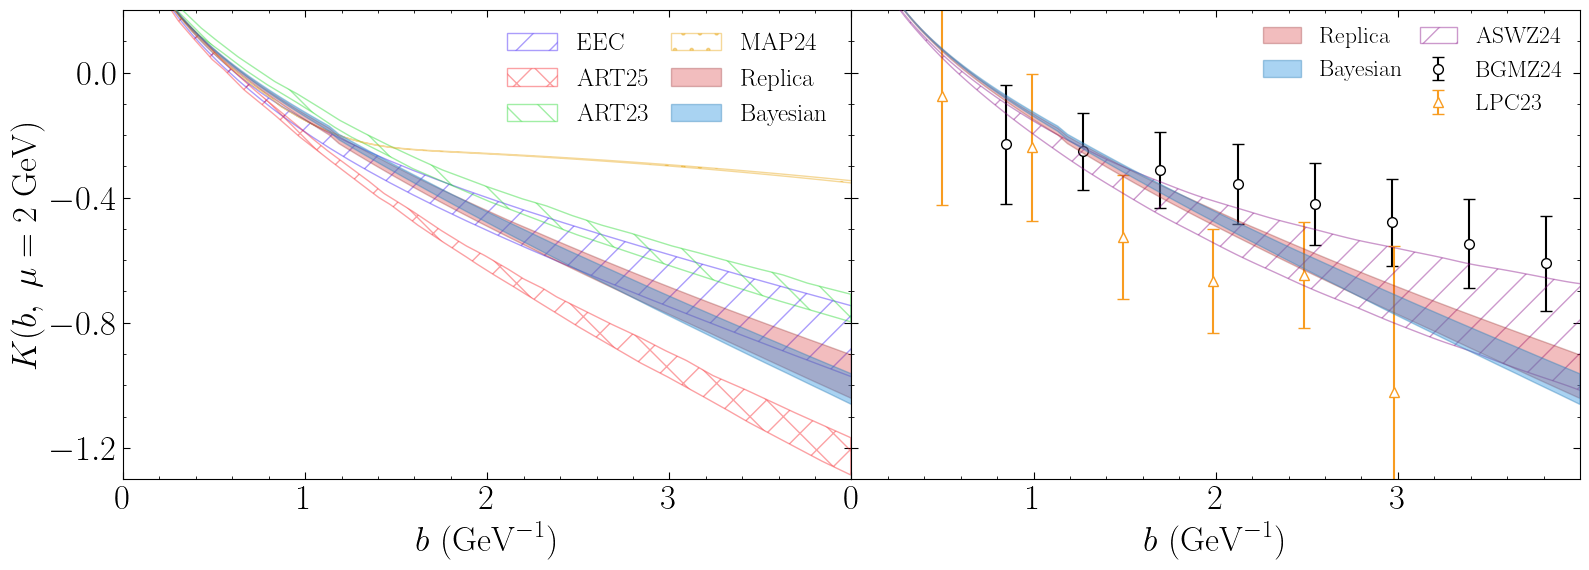

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.8), sharey=True)

blue = (0, 0, 1)
red = (1, 0, 0)
orange = (248/255, 156/255, 32/255)
eec_edge = "#2D0AF7"
art23_edge = "#14D61E"
art25_edge = "#F7151C"
map24_edge = '#E69F00'
agile_fill = '#D62728'
agile_edge = '#8B1E1E'
agile_bayes_fill = "#2A91DF"
agile_bayes_edge = '#2C7FB8'
agile_replica_alpha = 0.3
agile_bayes_alpha = 0.40

sizeOfFont = 25
sizeOfTick = 25
widthOfLine = 2
transOfBands = 0.3
transOfHatch = 0.4

# Upper panel
ax1.fill_between(
    bbstar['b'],
    bbstar['lower'],
    bbstar['upper'],
    alpha=transOfHatch,
    color='None',
    hatch='/',
    edgecolor=eec_edge,
    linewidth=1.0,
    zorder=1,
    label=r'\rm $ \rm{EEC}$',
)
ax1.fill_between(
    art25['b'],
    art25['lower'],
    art25['upper'],
    alpha=transOfHatch,
    color='None',
    hatch='x',
    edgecolor=art25_edge,
    linewidth=1.0,
    zorder=2,
    label=r'\rm $ \rm{ART25}$',
)
ax1.fill_between(
    art23['b'],
    art23['lower'],
    art23['upper'],
    alpha=transOfHatch,
    color='None',
    label=r'\rm $ \rm{ART23}$',
    hatch='\\',
    edgecolor=art23_edge,
    linewidth=1.0,
    zorder=3,
)
ax1.fill_between(
    map24['b'],
    map24['lower'],
    map24['upper'],
    alpha=transOfHatch,
    color='None',
    label=r'\rm $ \rm{MAP24}$',
    hatch='.',
    edgecolor=map24_edge,
    linewidth=1.0,
    zorder=4,
)
ax1.fill_between(
    agile_replica['b'],
    agile_replica['lower'],
    agile_replica['upper'],
    alpha=agile_replica_alpha,
    color=agile_fill,
    edgecolor=agile_edge,
    linewidth=1.0,
    zorder=10,
    label=r'\rm $ \rm{Replica}$',
)
ax1.fill_between(
    agile_bayesian['b'],
    agile_bayesian['lower'],
    agile_bayesian['upper'],
    alpha=agile_bayes_alpha,
    color=agile_bayes_fill,
    edgecolor=agile_bayes_edge,
    linewidth=1.0,
    zorder=11,
    label=r'\rm $ \rm{Bayesian}$',
)
# Lower panel
ax2.errorbar(
    GEV_PER_FM * bgmz24['b'],
    bgmz24['central'],
    bgmz24['error'],
    fmt='o',
    label=r'\rm $ \rm{BGMZ24} $',
    color='black',
    capsize=4,
    markersize=7,
    mfc='w',
    zorder=1,
)
ax2.errorbar(
    GEV_PER_FM * lpc23['b'],
    lpc23['central'],
    lpc23['error'],
    fmt='^',
    label=r'\rm $ \rm{LPC23} $',
    color=orange,
    capsize=4,
    markersize=7,
    mfc='w',
    zorder=2,
)
ax2.fill_between(
    aswz24['b'],
    aswz24['lower'],
    aswz24['upper'],
    alpha=transOfHatch,
    color='None',
    hatch='/',
    edgecolor='purple',
    zorder=3,
    label=r'\rm $ \rm{ASWZ24} $',
)
ax2.fill_between(
    agile_replica['b'],
    agile_replica['lower'],
    agile_replica['upper'],
    alpha=agile_replica_alpha,
    color=agile_fill,
    edgecolor=agile_edge,
    linewidth=1.0,
    zorder=10,
    label=r'\rm $ \rm{Replica}$',
)
ax2.fill_between(
    agile_bayesian['b'],
    agile_bayesian['lower'],
    agile_bayesian['upper'],
    alpha=agile_bayes_alpha,
    color=agile_bayes_fill,
    edgecolor=agile_bayes_edge,
    linewidth=1.0,
    zorder=11,
    label=r'\rm $ \rm{Bayesian}$',
)

for ax in [ax1, ax2]:
    ax.minorticks_on()
    ax.tick_params(axis='both', direction='in', length=5, labelsize=sizeOfTick, top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in', length=2.5, labelsize=sizeOfTick, top=True, right=True)

handles1, labels1 = ax1.get_legend_handles_labels()
order1 = [
    labels1.index(r'\rm $ \rm{EEC}$'),
    labels1.index(r'\rm $ \rm{ART25}$'),
    labels1.index(r'\rm $ \rm{ART23}$'),
    labels1.index(r'\rm $ \rm{MAP24}$'),
    labels1.index(r'\rm $ \rm{Replica}$'),
    labels1.index(r'\rm $ \rm{Bayesian}$'),
]
ax1.legend( 
    [handles1[idx] for idx in order1],
    [labels1[idx] for idx in order1],
    frameon=False,
    fontsize=0.72 * sizeOfTick,
    loc='upper right',
    ncol=2,
    columnspacing=0.9,
)
ax1.set_xlim(0, 4)
ax1.set_xticks([0.0, 1.0, 2.0, 3.0])
ax1.set_ylim(-1.3, 0.2)
ax1.set_yticks([0.0, -0.4, -0.8, -1.2])

handles2, labels2 = ax2.get_legend_handles_labels()
legend2 = {label: handle for handle, label in zip(handles2, labels2)}
blank_handle = Patch(facecolor='none', edgecolor='none')
ordered_handles2 = [
    legend2[r'\rm $ \rm{Replica}$'],
    legend2[r'\rm $ \rm{Bayesian}$'],
    blank_handle,
    legend2[r'\rm $ \rm{ASWZ24} $'],
    legend2[r'\rm $ \rm{BGMZ24} $'],
    legend2[r'\rm $ \rm{LPC23} $'],
]
ordered_labels2 = [
    r'\rm $ \rm{Replica}$',
    r'\rm $ \rm{Bayesian}$',
    '',
    r'\rm $ \rm{ASWZ24} $',
    r'\rm $ \rm{BGMZ24} $',
    r'\rm $ \rm{LPC23} $',
]
ax2.legend(
    ordered_handles2,
    ordered_labels2,
    frameon=False,
    fontsize=0.68 * sizeOfTick,
    loc='upper right',
    ncol=2,
    handlelength=1.6,
    columnspacing=0.7,
    borderaxespad=0.3,
)
ax1.set_xlabel(r'\rm $ b \ (\text{GeV}^{-1}) $', fontsize=sizeOfFont)
ax1.set_ylabel(r'\rm $ K(b, \ \mu=2 \ \rm{GeV}) $', fontsize=sizeOfFont)
ax2.set_xlim(0, 4.0)
ax2.set_xticks([0.0, 1.0, 2.0, 3.0])
ax2.set_xlabel(r'\rm $ b \ (\text{GeV}^{-1}) $', fontsize=sizeOfFont)
ax2.tick_params(labelleft=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0)
plt.show()
fig.savefig('CS.pdf')
